In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.data_utils.utils import load_csv

## Audiogram dataset

### Prepare dataset and plotting functions

In [97]:
### load data and rename
data_dir = 'data/sd-1001-2014-0/CSV'
df = load_csv(filepath=f'{data_dir}/Paper1_WebData_Final.csv')
df = df.rename(columns={'L500k': 'L500', 'R500k': 'R500'})

age_group_map = {1: "18-25", 2: "26-35", 3: "36-45", 4: "46-55", 5: "56-65"}
audiogram_cols = ['L500', 'L1k', 'L2k', 'L3k', 'L4k', 'L6k', 'L8k', 'R500', 'R1k', 'R2k', 'R3k', 'R4k', 'R6k', 'R8k']

Remove entries where the audiogram thresholds are missing. Quoted from the documentation:

Hearing thresholds in decibels on the Hearing Level scale (dB HL) contain codes assigned by 
NIOSH if the provider data explicitly indicated the worker refused to be tested, that there was 
no response at maximum value, or that an ear/frequency was not tested: 

* 997 = refusal to test 

* 998 = no response at maximum value 

* 999 = not tested

In [99]:
### preprocess dataset
def set_missing_to_nan(df: pd.DataFrame, col: str):
    missing_idx = df.loc[df[col].isin([997, 998, 999])].index
    df.loc[missing_idx, col] = np.nan
    return df

def isNan(element):
    return element != element


for col in audiogram_cols:
    df = set_missing_to_nan(df, col)


print(f'n.o. left 8000 Hz missing values: {len(df.loc[isNan(df['L8k']) == True])}')
print(f'n.o. left 8000 Hz missing values: {len(df.loc[isNan(df['R8k']) == True])}')

n.o. left 8000 Hz missing values: 317647
n.o. left 8000 Hz missing values: 317669


In [98]:
def plot_age_group_hist(df):
    age_group_vals, age_group_counts = np.unique(df['age_group'],return_counts=True)
    # Map age group values to their labels
    age_group_labels = [age_group_map[val] for val in age_group_vals]
    plt.bar(age_group_labels, age_group_counts, color='skyblue')
    plt.xlabel('Age Group')
    plt.ylabel('Count')
    plt.title('Age Group Distribution')
    plt.show()

In [103]:
def plot_audiogram_hists(df):

    # Compute mean and variance for each audiogram column
    mean_vals = df[audiogram_cols].mean()
    var_vals = df[audiogram_cols].var()

    # Plot 1: Mean with variance as bounds
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot the mean
    ax.bar(audiogram_cols, mean_vals, yerr=np.sqrt(var_vals), capsize=5, color='lightblue', alpha=0.7)
    ax.set_title('Mean with Variance Bounds of Audiogram Columns')
    ax.set_ylabel('Hearing threshold (Mean ± std)')
    ax.set_xlabel('Frequency (Hz)')
    plt.show()

    # Plot 2-6: Mean with variance bounds conditioned on age groups
    fig, axes = plt.subplots(2, 3, figsize=(15, 10), sharey=True)

    for idx, age_group in enumerate(age_group_map.keys()):
        filtered_df = df.loc[df['age_group'] == age_group][audiogram_cols]
        mean_vals_age = filtered_df.mean()
        var_vals_age = filtered_df.var()

        ax = axes[idx // 3, idx % 3]  # Determine subplot position
        ax.bar(audiogram_cols, mean_vals_age, yerr=np.sqrt(var_vals_age), capsize=5, color='lightcoral', alpha=0.7)
        ax.set_title(f'Age Group: {age_group_map[age_group]}')
        ax.set_ylabel('Hearing threshold (Mean ± std)')
        ax.set_xlabel('Frequency (Hz)')

    plt.tight_layout()
    plt.show()

In [102]:
def plot_industry_hist(df):
    industry_vals, industry_counts = np.unique(df['naics'],return_counts=True)
    standardized_counts = (industry_counts - np.mean(industry_counts)) / np.std(industry_counts)
    # Map age group values to their labels
    plt.bar(list(range(len(industry_vals))), standardized_counts, color='skyblue')
    plt.xlabel('Industry idx')
    plt.ylabel('Standardized counts')
    plt.title('Histogram over industries')
    plt.show()

### Display plots

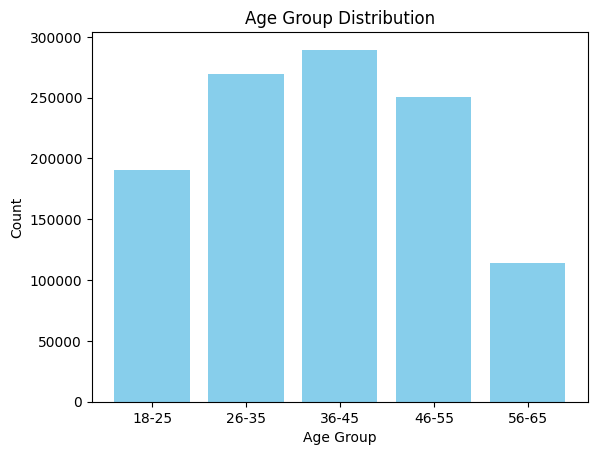

In [101]:
plot_age_group_hist(df)

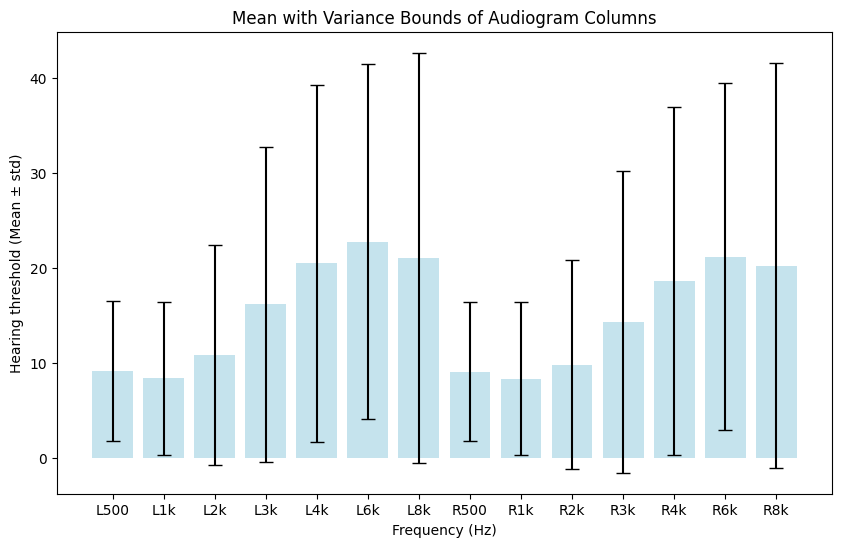

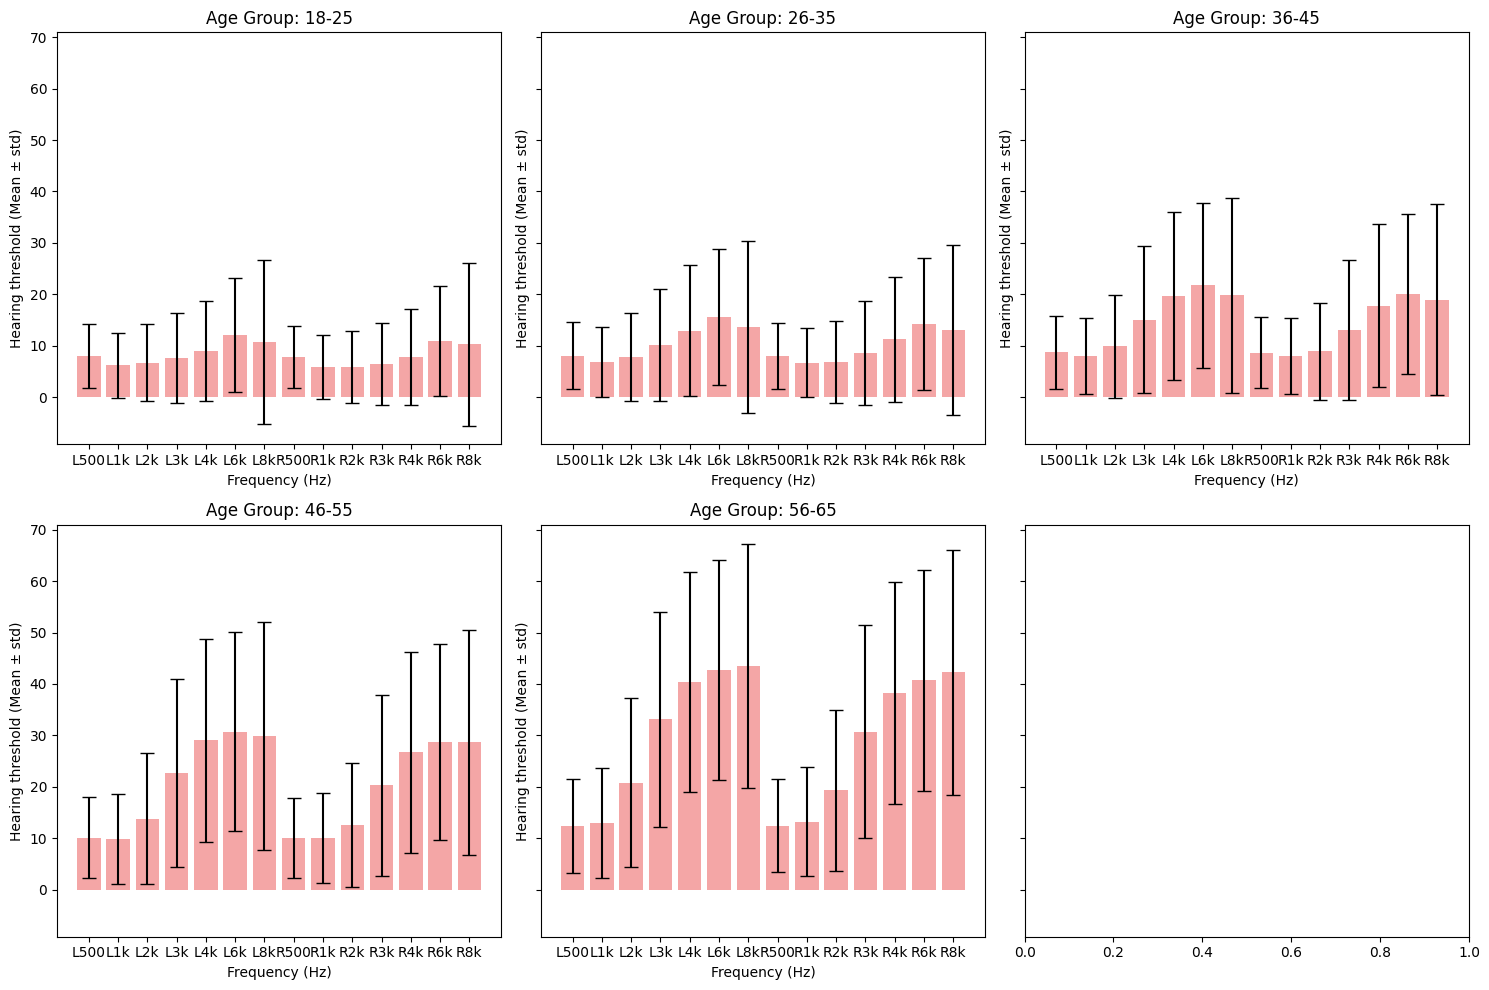

In [104]:
plot_audiogram_hists(df)

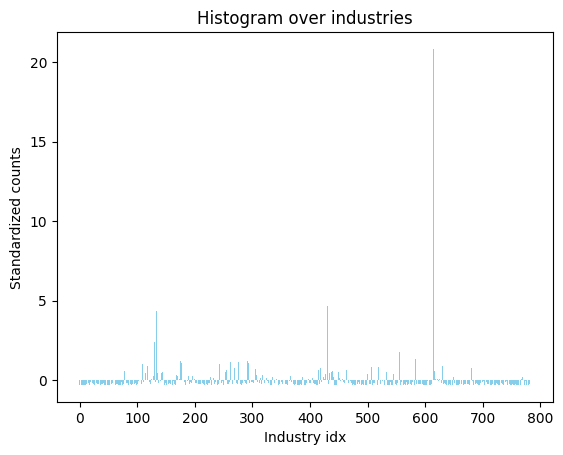

In [105]:
plot_industry_hist(df)

## Text dataset